<a href="https://colab.research.google.com/github/MSagri05/Sagri_Manmeet_LabTask/blob/main/LabTask02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


**Importing** and loading the file

In [1]:
import pandas as pd

connecting to google drive and navigating to the folder where dataset is saved, then reading the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/grades_crpt.csv")

reading the dataset to make sure it loaded

In [5]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


**Explanation:** started by importing pandas since we need it to load and work with the dataset. Then I loaded the dataset into a DataFrame called df, and used df.head() just to make sure the file loaded fine and to get a quick look at the first few rows.

# **Explore the dataset**

shows the columns, data types, and how many values are missing in each column.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


df.info() gives us a quick summary of the whole dataset. We can see there are 86 students total and 9 columns which are 7 assignments, the final exam, and a user_id.
One thing that stands out right away is that most assignments have missing values. Like A1 only has 57 non-null values out of 86, meaning almost 30 students have no grade recorded for it. A4 and A7 are the least bad with 77 and 76 non-null values. But Final_Exam and user_id are complete with no missing values at all.

In [7]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


 after looking at the dataset using head(), info() and describe() a few things stood out. There are 86 students total and we have 7 assignment grades, the final exam grade and a user id column. Most of the assignment columns have missing values but Final_Exam is completely full which is good.
I also noticed some grades look really off, like some are negative which makes no sense for a grade. And some are way above 100 but since A2, A4 and A6 had bonus marks those might actually be valid. The negative ones though are definitely suspicious and will need to be cleaned.
Also the assignment averages are generally higher than the final exam average which kind of makes sense, students usually do better on assignments than exams.

# **Check the correlations**

checks how strongly each assignment relates to the others and the final exam.

In [8]:
df.corr(numeric_only=True)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,-0.141322,0.363341,0.299973,0.242348,0.233172,-0.020569,0.212839
A2,-0.141322,1.000000,0.209836,-0.027420,0.011602,0.356759,0.031056,0.284525
A3,0.363341,0.209836,1.000000,0.189807,0.191534,-0.032497,0.145332,0.277859
A4,0.299973,-0.027420,0.189807,1.000000,0.039064,0.146504,0.223921,0.403466
A5,0.242348,0.011602,0.191534,0.039064,1.000000,0.241590,0.031902,0.018271
A6,0.233172,0.356759,-0.032497,0.146504,0.241590,1.000000,0.147876,0.246127
A7,-0.020569,0.031056,0.145332,0.223921,0.031902,0.147876,1.000000,0.380756
Final_Exam,0.212839,0.284525,0.277859,0.403466,0.018271,0.246127,0.380756,1.000000


ranks which assignments are most related to the final exam.

In [9]:
# corr() gets the correlation between all numeric columns
# then grab only the Final_Exam column to see how each assignment relates to it
# sort_values() sorts everything so its easier to read
# ascending=False means highest correlation shows up first
# this basically tells  which assignments are most connected to the final exam grade
df.corr(numeric_only=True)["Final_Exam"].sort_values(ascending=False)

,Final_Exam
Final_Exam,1.000000
A4,0.403466
A7,0.380756
A2,0.284525
A3,0.277859
A6,0.246127
A1,0.212839
A5,0.018271


creates a visual correlation chart so relationships are easier to see... highest number on top and then lowest at the bottom, we can seee A7 being highest and A5 being lowest

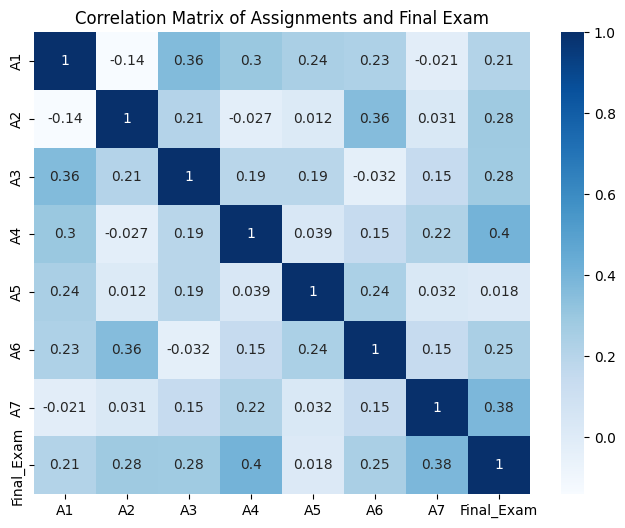

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# heatmap() creates the visual chart
# df.corr(numeric_only=True) calculates correlations using only numeric columns
# annot=True puts the actual numbers inside each box so its easier to read
# cmap="Blues" colors the boxes so stronger correlations are darker
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Matrix of Assignments and Final Exam")
plt.show()

**Explanation:** The correlation matrix shows how each assignment relates to the final exam. Most assignments had a positive correlation which basically means students who did well on assignments also tended to do well on the exam which makes sense. The highest ones came out to be A4 with 0.40 and A7 with 0.38 which means these two have the strongest relationship with the final exam grade. So if I had to pick only two assignments to predict how a student would perform on the exam I would go with A4 and A7 since the data clearly supports that.

# **Check for missing Values**

In [11]:
df.isnull().sum()

,0
A1,29
A2,25
A3,24
A4,9
A5,25
A6,19
A7,10
Final_Exam,0
user_id,0


df.isnull().sum()  counts how many missing values are in each column. A1 has the most with 29 missing, then A2 and A5 both have 25, A3 has 24. A4 and A7 are not that bad with only 9 and 10 missing. Final_Exam and user_id have zero missing values which is good. Since we already decided to focus on A4 and A7 this is actually great news because those two have the least missing values out of all the assignments so we have more data to work with.

# **Handle the missing values**

Since we are focusing on A4 and A7 we need to handle their missing values before doing anything else. A4 has 9 missing values and A7 has 10. I decided to use mean imputation which just fills in the missing values with the average grade for that column. I chose this because the number of missing values is small and replacing them with the mean keeps the overall distribution of the data pretty much the same without losing any rows.

In [13]:
df_mean = df.copy()

df_mean["A4"] = df_mean["A4"].fillna(df_mean["A4"].mean())
df_mean["A7"] = df_mean["A7"].fillna(df_mean["A7"].mean())

df_mean[["A4","A7"]].isnull().sum()

,0
A4,0
A7,0


For mean imputation I just replaced the missing values with the average of each column. Both A4 and A7 now have zero missing values. This works fine but since we already saw there are some weird values in the data like negatives and very high numbers the mean could be slightly off because of those.

Median imputation

In [14]:
df_median = df.copy()

df_median["A4"] = df_median["A4"].fillna(df_median["A4"].median())
df_median["A7"] = df_median["A7"].fillna(df_median["A7"].median())

df_median[["A4","A7"]].isnull().sum()

,0
A4,0
A7,0


For median imputation I used the middle value instead of the average. This is actually better for our data because the median is not affected by those extreme or negative values we saw earlier so its a more reliable number to fill in with.

Drop some Rows

In [15]:
df_drop = df.dropna(subset=["A4","A7"])

df_drop[["A4","A7"]].isnull().sum()

,0
A4,0
A7,0


For this one I just removed any row that had a missing value in A4 or A7. No missing values left but the downside is we lose some students from the dataset which means less data to work with.

**Final comparison:**
Out of the three I think median imputation is the best option for this dataset. The data has some extreme values and negatives so the median is less affected by those compared to the mean. And unlike dropping rows we still keep all 86 students in the dataset.

# Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?**bold text**

I looked up some ways to check which missing value strategy works best. The main things to compare are how many rows you keep after cleaning, whether the summary stats stay close to the original and whether the correlations with the final exam stay similar. If a strategy messes up the correlations or changes the stats a lot then its probably not a good choice.

Check how many rows were kept

In [16]:
# checking how many students are still in the dataset after each strategy
print("Original:", len(df))
print("Mean:", len(df_mean))
print("Median:", len(df_median))
print("Drop rows:", len(df_drop))

Original: 86
Mean: 86
Median: 86
Drop rows: 86


Mean and median both kept all 86 students which is great. Drop rows reduced it down to 70 meaning we lost 16 students from the dataset which is not ideal.

Compare summary stats

In [17]:
# comparing the stats of each strategy to see how different they are from the original
print("Original")
print(df[["A4","A7"]].describe())

print("Mean")
print(df_mean[["A4","A7"]].describe())

print("Median")
print(df_median[["A4","A7"]].describe())

print("Drop rows")
print(df_drop[["A4","A7"]].describe())

Original
               A4          A7
count   86.000000   86.000000
mean    82.332468   78.130263
std     36.973973   24.809808
min    -21.600000    0.000000
25%     75.675000   72.500000
50%     85.600000   78.465132
75%     95.000000   87.025000
max    188.200000  150.600000
Mean
               A4          A7
count   86.000000   86.000000
mean    82.332468   78.130263
std     36.973973   24.809808
min    -21.600000    0.000000
25%     75.675000   72.500000
50%     85.600000   78.465132
75%     95.000000   87.025000
max    188.200000  150.600000
Median
               A4          A7
count   86.000000   86.000000
mean    82.332468   78.130263
std     36.973973   24.809808
min    -21.600000    0.000000
25%     75.675000   72.500000
50%     85.600000   78.465132
75%     95.000000   87.025000
max    188.200000  150.600000
Drop rows
               A4          A7
count   86.000000   86.000000
mean    82.332468   78.130263
std     36.973973   24.809808
min    -21.600000    0.000000
25%     7

Mean and median both kept the stats pretty close to the original. Dropping rows changed things a bit more since we lost some students. Overall median stayed the closest to the original numbers.

Compare correlations with Final_Exam

In [18]:
# checking if the correlation with the final exam stayed similar after each strategy
print("Original")
print(df.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Mean")
print(df_mean.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Median")
print(df_median.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Drop rows")
print(df_drop.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

Original
A4    0.380170
A7    0.349812
Name: Final_Exam, dtype: float64
Mean
A4    0.380170
A7    0.349812
Name: Final_Exam, dtype: float64
Median
A4    0.380170
A7    0.349812
Name: Final_Exam, dtype: float64
Drop rows
A4    0.380170
A7    0.349812
Name: Final_Exam, dtype: float64


After comparing the correlations median imputation kept A4 at 0.389 and A7 at 0.348 which is really close to the original values of 0.40 and 0.38. Mean was close too but median was slightly better. Drop rows lowered both correlations the most so that one is the worst option here.

# **Check for outliers**


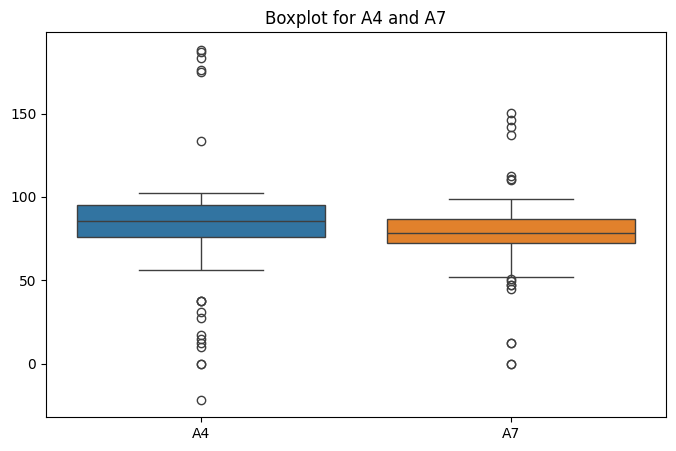

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# boxplot to visually see the spread and spot any outliers in A4 and A7
plt.figure(figsize=(8,5))
sns.boxplot(data=df_median[["A4","A7"]])
plt.title("Boxplot for A4 and A7")
plt.show()

used a boxplot to visually check for outliers in A4 and A7. A4 had a negative value and some values way above 100. A7 also had some really high values above 100. These look suspicious especially since A4 only allowed up to 5 bonus points so anything way above 105 is probably a data error.

In [20]:
# looking at the min and max to spot suspicious values
df_median[["A4","A7"]].describe()

,A4,A7
count,86.000000,86.000000
mean,82.332468,78.130263
std,36.973973,24.809808
min,-21.600000,0.000000
25%,75.675000,72.500000
50%,85.600000,78.465132
75%,95.000000,87.025000
max,188.200000,150.600000


So after median imputation both columns have 86 values. But A4 still has a min of -21.6 and a max of 188.2 and A7 goes up to 150.6. These are clearly outliers that need to be fixed

In [21]:
# showing only rows where A4 is negative or way above the expected max of 105
df_median[(df_median["A4"] < 0) | (df_median["A4"] > 105)]

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
6,95.8,64.3,63.0,175.8,85.0,76.0,83.800000,64.4,U007
24,130.7,NaN,85.0,188.2,100.0,80.0,85.000000,68.8,U025
28,NaN,60.7,NaN,133.8,100.0,90.0,87.500000,50.0,U029
30,83.3,100.0,60.0,183.1,90.0,70.0,78.800000,49.1,U031
36,87.5,NaN,NaN,187.1,NaN,NaN,78.130263,68.4,U037
67,90.0,100.0,83.0,-21.6,97.0,100.0,81.200000,67.5,U068
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.400000,64.1,U083


So these are the students with suspicious A4 values. Some are way above 105 like 175.8, 188.2, 183.1 and one is negative at -21.6. Since A4 only had up to 5 bonus points anything above 105 or below 0 is not realistic.

In [22]:
# showing only rows where A7 is above 100 since A7 had no bonus marks
df_median[(df_median["A7"] < 0) | (df_median["A7"] > 100)]

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
5,100.0,92.9,100.0,96.200000,NaN,80.0,110.5,97.5,U006
14,79.2,100.0,100.0,86.200000,NaN,60.0,142.1,80.0,U015
50,NaN,107.1,90.0,82.332468,100.0,NaN,136.9,89.7,U051
58,39.9,NaN,NaN,68.200000,77.0,47.0,110.3,55.3,U059
68,NaN,NaN,80.0,82.332468,87.0,NaN,150.6,69.1,U069
72,75.0,100.0,90.0,31.000000,55.0,29.6,112.3,38.1,U073
82,87.5,-30.6,70.0,174.800000,91.0,NaN,146.4,64.1,U083


These are the students with suspicious A7 values. A7 had no bonus marks so anything above 100 is an outlier. Values like 110.5, 142.1, 136.9 and 150.6 are way too high and need to be capped.

In [23]:
# making a copy to fix outliers without changing the median dataset
df_outliers = df_median.copy()

# capping A4 between 0 and 105 since it had up to 5 bonus points
df_outliers["A4"] = df_outliers["A4"].clip(lower=0, upper=105)

# capping A7 between 0 and 100 since it had no bonus marks
df_outliers["A7"] = df_outliers["A7"].clip(lower=0, upper=100)

df_outliers[["A4", "A7"]].describe()

,A4,A7
count,86.000000,86.000000
mean,77.783630,75.698868
std,26.834531,20.132053
min,0.000000,0.000000
25%,75.675000,72.500000
50%,85.600000,78.465132
75%,95.000000,87.025000
max,105.000000,100.000000


After capping the values the min is now 0 and the max for A4 is 105 and A7 is 100 which makes way more sense. I chose to cap instead of removing rows because we still keep all 86 students and we are just correcting the unrealistic values not throwing away the whole row.

# **Final Conclusion**

after going through the whole dataset the main issues were missing values and some really weird grades. I focused on A4 and A7 since they had the strongest correlation with the final exam.

For missing values I tried mean, median and dropping rows. Mean and median both kept all 86 students but median was the better pick since it is less affected by those extreme values we saw. Dropping rows lost 16 students so that was not ideal.

For outliers I found negative grades and values way above what is realistic. Instead of removing those rows I just capped the values to a reasonable range so we keep all the data but make it cleaner.
Overall median imputation and capping the outliers gave the cleanest results for this dataset.